# Diabetes Patient Outcomes & Risk Analytics

## Python Data Preparation and Exploratory Data Analysis

### Objective

This notebook performs data quality assessment, cleaning, feature engineering, and exploratory data analysis on a patient-level diabetes dataset.

The analysis focuses on identifying demographic and clinical patterns associated with diabetes while preparing a clean analytical dataset for subsequent statistical modeling and visualization.

### Python Tools

- **Pandas** — data manipulation and analysis
- **NumPy** — numerical operations
- **Matplotlib** — data visualization

### Analytical Workflow

1. Import and inspect the raw dataset
2. Assess data quality
3. Identify and remove duplicate records
4. Validate categorical and numerical variables
5. Engineer analytical features
6. Perform exploratory data analysis
7. Visualize important patterns
8. Export the cleaned dataset for statistical modeling

In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings for cleaner notebook output
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Import

The raw diabetes dataset is loaded directly from the project's `data/raw` directory. The original file is preserved unchanged to maintain a reproducible separation between raw and processed data.

In [3]:
# Load the raw dataset

data_path = "../data/raw/diabetes_prediction_dataset.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 100,000
Columns: 9


## 3. Initial Data Assessment

Before cleaning or analyzing the data, the dataset is examined to understand its structure, variable types, completeness, distributions, and potential data-quality issues.

In [4]:
# ============================================================
# 3. INITIAL DATA ASSESSMENT
# ============================================================

# Display the first five observations
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,never,25.19,6.60,140,0
1,Female,54.00,0,0,No Info,27.32,6.60,80,0
2,Male,28.00,0,0,never,27.32,5.70,158,0
3,Female,36.00,0,0,current,23.45,5.00,155,0
4,Male,76.00,1,1,current,20.14,4.80,155,0


In [5]:
# Inspect dataset structure and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


In [6]:
# Generate descriptive statistics for numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.00,41.89,22.52,0.08,24.00,43.00,60.00,80.00
hypertension,100000.00,0.07,0.26,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.00,0.04,0.19,0.00,0.00,0.00,0.00,1.00
bmi,100000.00,27.32,6.64,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.00,5.53,1.07,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.00,138.06,40.71,80.00,100.00,140.00,159.00,300.00
diabetes,100000.00,0.09,0.28,0.00,0.00,0.00,0.00,1.00


In [7]:
# Check for missing values

missing_values = (
    df.isnull()
      .sum()
      .to_frame(name="missing_count")
)

missing_values["missing_percentage"] = (
    missing_values["missing_count"] / len(df) * 100
).round(2)

missing_values

,missing_count,missing_percentage
gender,0,0.00
age,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
smoking_history,0,0.00
bmi,0,0.00
HbA1c_level,0,0.00
blood_glucose_level,0,0.00
diabetes,0,0.00


In [8]:
# Check for duplicate patient records

duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate records: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate records: 3,854
Duplicate percentage: 3.85%


## 4. Data Cleaning

The initial assessment identified 3,854 duplicate records, representing 3.85% of the raw dataset. These duplicate observations are removed before further analysis to prevent repeated records from influencing descriptive statistics and subsequent modeling.

The original raw dataset remains unchanged. All cleaning operations are performed on a separate copy of the data.

In [9]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

# Create a working copy to preserve the raw imported dataset
df_clean = df.copy()

print(f"Raw dataset: {len(df):,} rows")
print(f"Working dataset: {len(df_clean):,} rows")

Raw dataset: 100,000 rows
Working dataset: 100,000 rows


In [10]:
# Remove exact duplicate records

rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print(f"Rows before cleaning: {rows_before:,}")
print(f"Duplicate rows removed: {rows_removed:,}")
print(f"Rows after cleaning: {rows_after:,}")

Rows before cleaning: 100,000
Duplicate rows removed: 3,854
Rows after cleaning: 96,146


In [11]:
# Verify that duplicate records have been removed

remaining_duplicates = df_clean.duplicated().sum()

print(f"Remaining duplicate records: {remaining_duplicates:,}")

Remaining duplicate records: 0


In [12]:
# Inspect categorical variables

categorical_columns = [
    "gender",
    "smoking_history"
]

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print("-" * 40)
    print(df_clean[column].value_counts(dropna=False))


GENDER
----------------------------------------
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

SMOKING_HISTORY
----------------------------------------
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


### Checking Numerical Variables

Before starting the analysis, I checked the numerical variables to make sure their values were reasonable. I also checked the yes/no variables to confirm that they were coded correctly as 0 and 1.

In [13]:
# Inspect ranges of continuous numerical variables

numerical_columns = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

df_clean[numerical_columns].agg(["min", "max", "mean", "median"]).T

,min,max,mean,median
age,0.08,80.00,41.79,43.00
bmi,10.01,95.69,27.32,27.32
HbA1c_level,3.50,9.00,5.53,5.80
blood_glucose_level,80.00,300.00,138.22,140.00


In [14]:
# Validate binary clinical and outcome variables

binary_columns = [
    "hypertension",
    "heart_disease",
    "diabetes"
]

for column in binary_columns:
    print(f"\n{column.upper()}")
    print("-" * 40)
    print(df_clean[column].value_counts(dropna=False).sort_index())


HYPERTENSION
----------------------------------------
hypertension
0    88685
1     7461
Name: count, dtype: int64

HEART_DISEASE
----------------------------------------
heart_disease
0    92223
1     3923
Name: count, dtype: int64

DIABETES
----------------------------------------
diabetes
0    87664
1     8482
Name: count, dtype: int64


In [16]:
# Check for values that may be incorrect

quality_checks = pd.DataFrame({
    "check": [
        "Age below 0",
        "BMI <= 0",
        "HbA1c <= 0",
        "Blood glucose <= 0"
    ],
    "records": [
        (df_clean["age"] < 0).sum(),
        (df_clean["bmi"] <= 0).sum(),
        (df_clean["HbA1c_level"] <= 0).sum(),
        (df_clean["blood_glucose_level"] <= 0).sum()
    ]
})

quality_checks

,check,records
0,Age below 0,0
1,BMI <= 0,0
2,HbA1c <= 0,0
3,Blood glucose <= 0,0


## 5. Creating Variables for Analysis

To make the results easier to interpret, I created age groups and BMI categories from the original numerical variables. The original age and BMI values are kept in the dataset.

In [17]:
# Create age groups

age_conditions = [
    df_clean["age"] < 30,
    (df_clean["age"] >= 30) & (df_clean["age"] < 45),
    (df_clean["age"] >= 45) & (df_clean["age"] < 60),
    df_clean["age"] >= 60
]

age_labels = [
    "Under 30",
    "30-44",
    "45-59",
    "60+"
]

df_clean["age_group"] = np.select(
    age_conditions,
    age_labels,
    default="Unknown"
)

df_clean["age_group"].value_counts()

age_group
Under 30    31174
60+         23975
45-59       21789
30-44       19208
Name: count, dtype: int64

In [18]:
# Create BMI categories

bmi_conditions = [
    df_clean["bmi"] < 18.5,
    (df_clean["bmi"] >= 18.5) & (df_clean["bmi"] < 25),
    (df_clean["bmi"] >= 25) & (df_clean["bmi"] < 30),
    df_clean["bmi"] >= 30
]

bmi_labels = [
    "Underweight",
    "Normal",
    "Overweight",
    "Obese"
]

df_clean["bmi_category"] = np.select(
    bmi_conditions,
    bmi_labels,
    default="Unknown"
)

df_clean["bmi_category"].value_counts()

bmi_category
Overweight     41917
Obese          23530
Normal         22208
Underweight     8491
Name: count, dtype: int64

In [19]:
# Preview the new variables

df_clean[
    ["age", "age_group", "bmi", "bmi_category", "diabetes"]
].head(10)

,age,age_group,bmi,bmi_category,diabetes
0,80.00,60+,25.19,Overweight,0
1,54.00,45-59,27.32,Overweight,0
2,28.00,Under 30,27.32,Overweight,0
3,36.00,30-44,23.45,Normal,0
4,76.00,60+,20.14,Normal,0
5,20.00,Under 30,27.32,Overweight,0
6,44.00,30-44,19.31,Normal,1
7,79.00,60+,23.86,Normal,0
8,42.00,30-44,33.64,Obese,0
9,32.00,30-44,27.32,Overweight,0


## 6. Exploratory Data Analysis

After cleaning the data, I explored the main characteristics of the study population and compared patients with and without diabetes. The goal is to identify patterns that can be investigated further in the statistical analysis.

In [20]:
# Calculate overall diabetes prevalence

diabetes_summary = (
    df_clean["diabetes"]
    .value_counts()
    .sort_index()
    .rename_axis("diabetes")
    .reset_index(name="patients")
)

diabetes_summary["percentage"] = (
    diabetes_summary["patients"] / len(df_clean) * 100
).round(2)

diabetes_summary

,diabetes,patients,percentage
0,0,87664,91.18
1,1,8482,8.82


In [21]:
# Compare average clinical measurements by diabetes status

clinical_summary = (
    df_clean
    .groupby("diabetes")
    .agg(
        patients=("diabetes", "size"),
        average_age=("age", "mean"),
        average_bmi=("bmi", "mean"),
        average_hba1c=("HbA1c_level", "mean"),
        average_glucose=("blood_glucose_level", "mean")
    )
    .round(2)
)

clinical_summary

,patients,average_age,average_bmi,average_hba1c,average_glucose
diabetes,,,,,
0,87664,39.94,26.87,5.40,132.82
1,8482,60.93,32.00,6.93,194.03


### Initial Finding

Patients with diabetes were generally older and had higher average BMI, HbA1c, and blood glucose levels than patients without diabetes. These are descriptive differences and do not yet account for other patient characteristics.

## 7. Data Visualization

Visualizations were created to make the main patterns in the cleaned dataset easier to understand and communicate.

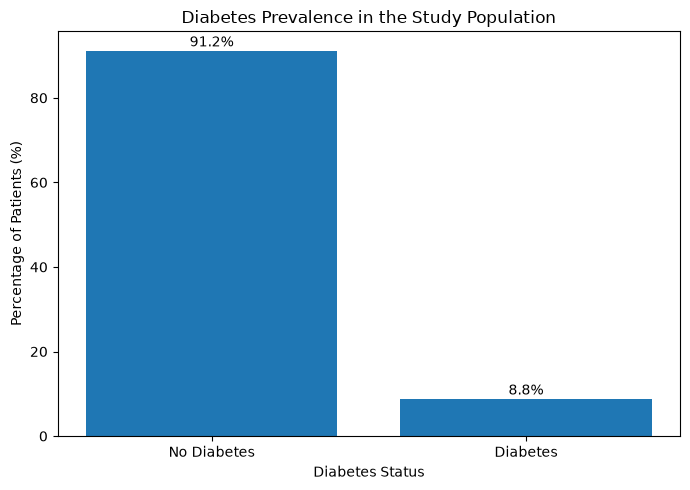

In [22]:
# Calculate prevalence for plotting

prevalence = (
    df_clean["diabetes"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Create chart

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["No Diabetes", "Diabetes"],
    prevalence.values
)

ax.set_title("Diabetes Prevalence in the Study Population")
ax.set_ylabel("Percentage of Patients (%)")
ax.set_xlabel("Diabetes Status")

# Add percentages above the bars
for bar, value in zip(bars, prevalence.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

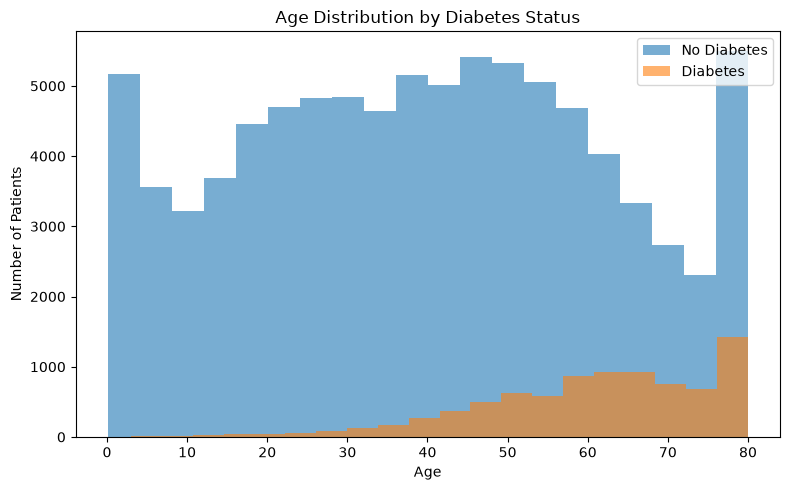

In [23]:
# Compare age distributions by diabetes status

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_clean.loc[df_clean["diabetes"] == 0, "age"],
    bins=20,
    alpha=0.6,
    label="No Diabetes"
)

ax.hist(
    df_clean.loc[df_clean["diabetes"] == 1, "age"],
    bins=20,
    alpha=0.6,
    label="Diabetes"
)

ax.set_title("Age Distribution by Diabetes Status")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Patients")
ax.legend()

plt.tight_layout()
plt.show()

### Age and Diabetes

Diabetes was more common among older patients in the dataset. Very few diabetes cases were observed at younger ages, while the number of cases increased noticeably after about age 40 and was highest among older patients.

The relationship between age and diabetes will be examined more closely in the statistical analysis.

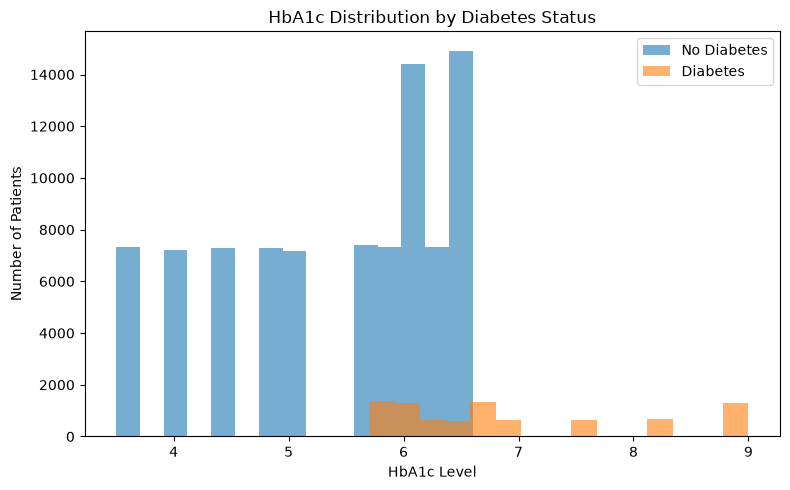

In [24]:
# Compare HbA1c distributions by diabetes status

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_clean.loc[df_clean["diabetes"] == 0, "HbA1c_level"],
    bins=15,
    alpha=0.6,
    label="No Diabetes"
)

ax.hist(
    df_clean.loc[df_clean["diabetes"] == 1, "HbA1c_level"],
    bins=15,
    alpha=0.6,
    label="Diabetes"
)

ax.set_title("HbA1c Distribution by Diabetes Status")
ax.set_xlabel("HbA1c Level")
ax.set_ylabel("Number of Patients")
ax.legend()

plt.tight_layout()
plt.show()

### HbA1c and Diabetes

Patients with diabetes generally had higher HbA1c levels than patients without diabetes. Most patients without diabetes were concentrated at lower HbA1c values, while diabetes cases became more common at higher values.

This pattern is expected because HbA1c is an important clinical measure used in the diagnosis and monitoring of diabetes. The statistical analysis will examine how HbA1c relates to diabetes alongside other patient characteristics.

In [25]:
# Calculate diabetes prevalence by age group

age_prevalence = (
    df_clean
    .groupby("age_group", as_index=False)
    .agg(
        total_patients=("diabetes", "size"),
        diabetes_cases=("diabetes", "sum")
    )
)

age_prevalence["diabetes_prevalence"] = (
    age_prevalence["diabetes_cases"]
    / age_prevalence["total_patients"]
    * 100
).round(2)

# Put age groups in the correct order
age_order = ["Under 30", "30-44", "45-59", "60+"]

age_prevalence["age_group"] = pd.Categorical(
    age_prevalence["age_group"],
    categories=age_order,
    ordered=True
)

age_prevalence = age_prevalence.sort_values("age_group")

age_prevalence

,age_group,total_patients,diabetes_cases,diabetes_prevalence
3,Under 30,31174,274,0.88
0,30-44,19208,832,4.33
1,45-59,21789,2458,11.28
2,60+,23975,4918,20.51


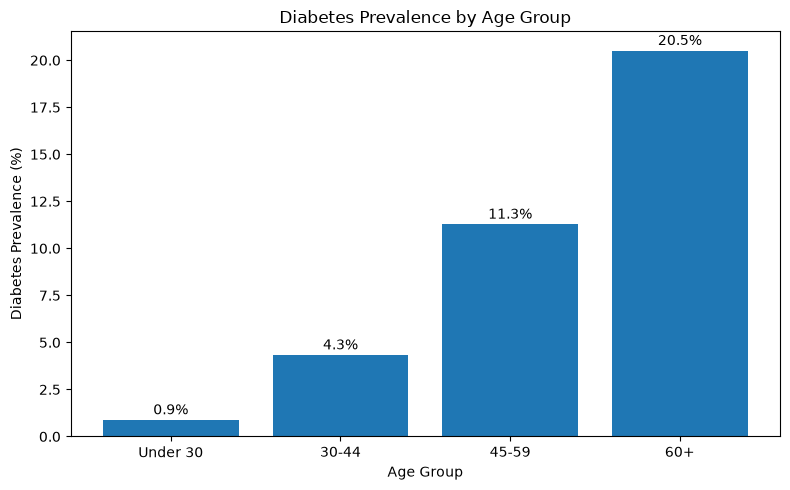

In [26]:
# Plot diabetes prevalence by age group

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    age_prevalence["age_group"],
    age_prevalence["diabetes_prevalence"]
)

ax.set_title("Diabetes Prevalence by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Diabetes Prevalence (%)")

# Add prevalence values above each bar
for bar, value in zip(
    bars,
    age_prevalence["diabetes_prevalence"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Diabetes Prevalence by Age

Diabetes prevalence increased steadily with age. It was 0.9% among patients under 30, 4.3% among patients aged 30–44, 11.3% among those aged 45–59, and 20.5% among patients aged 60 or older.

This suggests a strong relationship between age and diabetes in this dataset.

## 8. Relationships Between Clinical Variables

To better understand how the numerical variables are related, I calculated correlations between age, BMI, HbA1c, blood glucose, and diabetes status. 

In [27]:
# Select numerical variables for correlation analysis

correlation_variables = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "hypertension",
    "heart_disease",
    "diabetes"
]

correlation_matrix = (
    df_clean[correlation_variables]
    .corr()
    .round(2)
)

correlation_matrix

,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,diabetes
age,1.00,0.34,0.11,0.11,0.26,0.24,0.26
bmi,0.34,1.00,0.08,0.09,0.15,0.06,0.21
HbA1c_level,0.11,0.08,1.00,0.17,0.08,0.07,0.41
blood_glucose_level,0.11,0.09,0.17,1.00,0.08,0.07,0.42
hypertension,0.26,0.15,0.08,0.08,1.00,0.12,0.20
heart_disease,0.24,0.06,0.07,0.07,0.12,1.00,0.17
diabetes,0.26,0.21,0.41,0.42,0.20,0.17,1.00


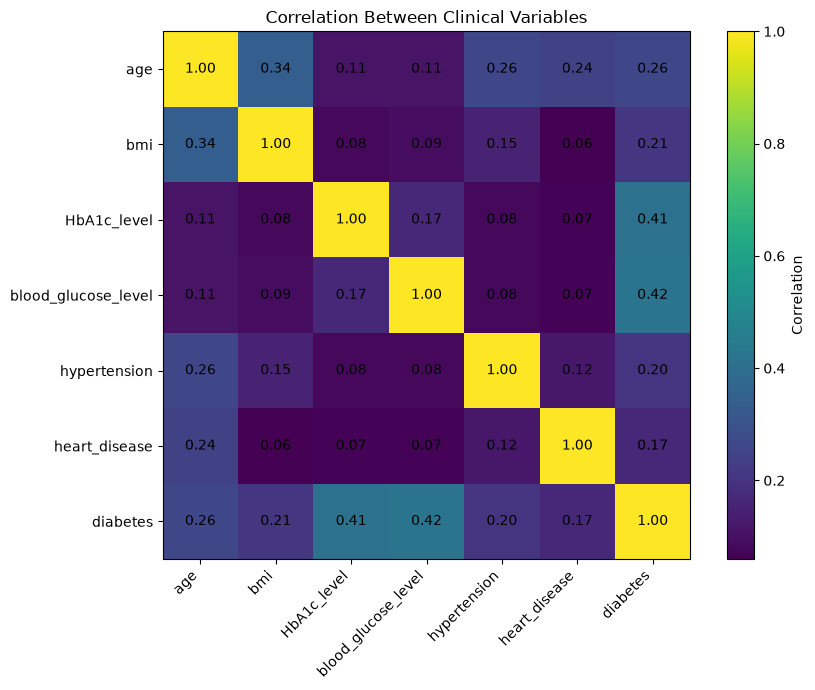

In [28]:
# Create a correlation heatmap

fig, ax = plt.subplots(figsize=(9, 7))

heatmap = ax.imshow(correlation_matrix)

ax.set_xticks(range(len(correlation_variables)))
ax.set_yticks(range(len(correlation_variables)))

ax.set_xticklabels(
    correlation_variables,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlation_variables)

# Display correlation values inside the heatmap
for i in range(len(correlation_variables)):
    for j in range(len(correlation_variables)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Between Clinical Variables")

fig.colorbar(heatmap, ax=ax, label="Correlation")

plt.tight_layout()
plt.show()

### Correlation with Diabetes

Blood glucose (r = 0.42) and HbA1c (r = 0.41) had the strongest positive correlations with diabetes in this dataset. Age (r = 0.26) and BMI (r = 0.21) also showed positive relationships with diabetes.

Hypertension (r = 0.20) and heart disease (r = 0.17) had weaker positive correlations.

## 9. Save the Cleaned Dataset

After completing the data checks and creating the additional analysis variables, I saved the cleaned dataset as a separate file. This keeps the original raw data unchanged and provides one consistent dataset for the next stages of the project.

In [29]:
# Save the cleaned dataset

output_path = "../data/processed/diabetes_clean.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Cleaned dataset saved successfully.")
print(f"Final number of rows: {len(df_clean):,}")
print(f"Final number of columns: {df_clean.shape[1]}")

Cleaned dataset saved successfully.
Final number of rows: 96,146
Final number of columns: 11


# Final check of the dataset prepared for analysis

print("FINAL DATASET")
print("-" * 40)
print(f"Rows: {df_clean.shape[0]:,}")
print(f"Columns: {df_clean.shape[1]}")
print(f"Missing values: {df_clean.isnull().sum().sum():,}")
print(f"Duplicate records: {df_clean.duplicated().sum():,}")

df_clean.head()

## 10. Statistical Analysis

The next step was to examine which patient characteristics were associated with diabetes. Since diabetes status has two possible outcomes (diabetes or no diabetes), logistic regression was used for the analysis.

The analysis included age, gender, BMI, HbA1c, blood glucose, hypertension, heart disease, and smoking history.

In [32]:
# Import the package used for statistical modeling

import statsmodels.api as sm
import statsmodels.formula.api as smf

print("Statsmodels loaded successfully.")

Statsmodels loaded successfully.


### 10.1 Diabetes Prevalence

Before fitting the statistical model, I calculated the overall prevalence of diabetes in the cleaned dataset.

In [33]:
# Calculate diabetes prevalence in the cleaned dataset

total_patients = len(df_clean)
diabetes_cases = df_clean["diabetes"].sum()
diabetes_prevalence = diabetes_cases / total_patients * 100

print(f"Total patients: {total_patients:,}")
print(f"Diabetes cases: {diabetes_cases:,}")
print(f"Diabetes prevalence: {diabetes_prevalence:.2f}%")

Total patients: 96,146
Diabetes cases: 8,482
Diabetes prevalence: 8.82%


### 10.2 Diabetes and Age
Question : Is age associated with diabetes ?

A logistic regression model was first used to examine the relationship between age and diabetes.

In [34]:
# Logistic regression: diabetes and age

age_model = smf.logit(
    formula="diabetes ~ age",
    data=df_clean
).fit()

print(age_model.summary())

Optimization terminated successfully.
         Current function value: 0.259554
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:                96146
Model:                          Logit   Df Residuals:                    96144
Method:                           MLE   Df Model:                            1
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                  0.1302
Time:                        17:30:55   Log-Likelihood:                -24955.
converged:                       True   LL-Null:                       -28690.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.9495      0.042   -118.632      0.000      -5.031      -4.868
age            0.0510      0.

In [35]:
# Convert the age coefficient to an odds ratio

age_coef = age_model.params["age"]
age_or = np.exp(age_coef)

age_ci = age_model.conf_int().loc["age"]
age_ci_lower = np.exp(age_ci[0])
age_ci_upper = np.exp(age_ci[1])

age_pvalue = age_model.pvalues["age"]

print(f"Odds Ratio for Age: {age_or:.3f}")
print(f"95% CI: {age_ci_lower:.3f} to {age_ci_upper:.3f}")
print(f"P-value: {age_pvalue:.4g}")

Odds Ratio for Age: 1.052
95% CI: 1.051 to 1.054
P-value: 0


### Interpretation

Pvalue < 0.001 so Age was significantly associated with diabetes. For each additional year of age, the odds of diabetes increased by approximately 5.2% (OR = 1.052, 95% CI: 1.051–1.054).

This result looks at age alone and does not account for other patient characteristics that may also be related to diabetes.

### 10.3 Multivariable Logistic Regression

I then fitted a multivariable logistic regression model to examine the relationship between patient characteristics and diabetes while accounting for the other variables in the model.

The model included age, BMI, HbA1c, blood glucose, hypertension, heart disease, gender, and smoking history.

In [38]:
# Fit the multivariable logistic regression model

full_model = smf.logit(
    formula="""
        diabetes ~ age
        + bmi
        + HbA1c_level
        + blood_glucose_level
        + hypertension
        + heart_disease
        + C(gender)
        + C(smoking_history)
    """,
    data=df_clean
).fit(maxiter=200)

print(full_model.summary())

         Current function value: 0.116300
         Iterations: 200


C:\Users\kadri\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:                96146
Model:                          Logit   Df Residuals:                    96132
Method:                           MLE   Df Model:                           13
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                  0.6103
Time:                        17:41:59   Log-Likelihood:                -11182.
converged:                      False   LL-Null:                       -28690.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -27.6462      0.294    -93.935      0.000     -28.223     -27.069
C(gender)[T.Male]                     0.2643      0.036      7

In [39]:
# Check whether the model converged

print("Model converged:", full_model.mle_retvals["converged"])

Model converged: False


### Checking the Model

The first multivariable model did not converge, which means the model could not estimate the results reliably. I therefore checked whether some variables or categories were separating patients with and without diabetes too strongly.

In [40]:
# Check diabetes cases across gender categories

pd.crosstab(
    df_clean["gender"],
    df_clean["diabetes"],
    margins=True
)

diabetes,0,1,All
gender,,,
Female,51714,4447,56161
Male,35932,4035,39967
Other,18,0,18
All,87664,8482,96146


In [41]:
# Check diabetes cases across smoking history categories

pd.crosstab(
    df_clean["smoking_history"],
    df_clean["diabetes"],
    margins=True
)

diabetes,0,1,All
smoking_history,,,
No Info,31442,1445,32887
current,8249,948,9197
ever,3526,472,3998
former,7709,1590,9299
never,31061,3337,34398
not current,5677,690,6367
All,87664,8482,96146


In [42]:
# Check the range of HbA1c for each diabetes group

df_clean.groupby("diabetes")["HbA1c_level"].agg(
    ["min", "max", "mean", "median"]
)

,min,max,mean,median
diabetes,,,,
0,3.50,6.60,5.40,5.80
1,5.70,9.00,6.93,6.60


In [43]:
# Check the range of blood glucose for each diabetes group

df_clean.groupby("diabetes")["blood_glucose_level"].agg(
    ["min", "max", "mean", "median"]
)

,min,max,mean,median
diabetes,,,,
0,80,200,132.82,140.00
1,126,300,194.03,160.00


### Model Check

The initial model did not converge, so I checked the variables for categories or values that might be causing the problem.

The "Other" gender category contained only 18 patients and no diabetes cases. Because this group was very small and had no outcome variation, it could make the logistic regression estimates unstable.

HbA1c and blood glucose also showed strong differences between patients with and without diabetes, although their values still overlapped between the two groups.

In [44]:
# Test the model without gender

model_no_gender = smf.logit(
    formula="""
        diabetes ~ age
        + bmi
        + HbA1c_level
        + blood_glucose_level
        + hypertension
        + heart_disease
        + C(smoking_history)
    """,
    data=df_clean
).fit(maxiter=200)

print("Model converged:", model_no_gender.mle_retvals["converged"])

Optimization terminated successfully.
         Current function value: 0.116580
         Iterations 10
Model converged: True


### Model Adjustment

After removing gender from the model, the logistic regression converged successfully. This suggests that the very small "Other" gender category, which contained only 18 patients and no diabetes cases, was contributing to the convergence problem.

Gender was therefore excluded from the final model rather than removing patients from the dataset.

In [45]:
# Create a table of results from the final model

model_results = pd.DataFrame({
    "Odds Ratio": np.exp(model_no_gender.params),
    "CI Lower": np.exp(model_no_gender.conf_int()[0]),
    "CI Upper": np.exp(model_no_gender.conf_int()[1]),
    "P-value": model_no_gender.pvalues
})

model_results = model_results.drop("Intercept")

model_results = model_results.round({
    "Odds Ratio": 3,
    "CI Lower": 3,
    "CI Upper": 3,
    "P-value": 4
})

model_results

,Odds Ratio,CI Lower,CI Upper,P-value
C(smoking_history)[T.current],1.92,1.68,2.18,0.00
C(smoking_history)[T.ever],1.80,1.52,2.13,0.00
C(smoking_history)[T.former],1.72,1.53,1.94,0.00
C(smoking_history)[T.never],1.59,1.45,1.76,0.00
C(smoking_history)[T.not current],1.52,1.31,1.77,0.00
age,1.05,1.05,1.05,0.00
bmi,1.09,1.08,1.10,0.00
HbA1c_level,10.34,9.64,11.10,0.00
blood_glucose_level,1.03,1.03,1.03,0.00
hypertension,2.05,1.87,2.24,0.00


### 10.4 Adjusted Model Results

The table below shows the adjusted odds ratios from the final logistic regression model. Each odds ratio represents the relationship between a patient characteristic and diabetes while accounting for the other variables included in the model.

In [46]:
# Create a clean table for reporting the regression results

final_results = pd.DataFrame({
    "Variable": [
        "Current smoker vs No Info",
        "Ever smoked vs No Info",
        "Former smoker vs No Info",
        "Never smoked vs No Info",
        "Not current smoker vs No Info",
        "Age (per 1-year increase)",
        "BMI (per 1-unit increase)",
        "HbA1c (per 1-unit increase)",
        "Blood glucose (per 1-unit increase)",
        "Hypertension (Yes vs No)",
        "Heart disease (Yes vs No)"
    ],
    
    "Odds Ratio": model_results["Odds Ratio"].values,
    "95% CI": [
        f"{low:.2f}–{high:.2f}"
        for low, high in zip(
            model_results["CI Lower"],
            model_results["CI Upper"]
        )
    ],
    
    "P-value": [
        "<0.001" if p < 0.001 else f"{p:.3f}"
        for p in model_no_gender.pvalues.drop("Intercept")
    ]
})

final_results

,Variable,Odds Ratio,95% CI,P-value
0,Current smoker vs No Info,1.92,1.68–2.18,<0.001
1,Ever smoked vs No Info,1.80,1.52–2.13,<0.001
2,Former smoker vs No Info,1.72,1.53–1.94,<0.001
3,Never smoked vs No Info,1.59,1.45–1.76,<0.001
4,Not current smoker vs No Info,1.52,1.31–1.77,<0.001
5,Age (per 1-year increase),1.05,1.05–1.05,<0.001
6,BMI (per 1-unit increase),1.09,1.08–1.10,<0.001
7,HbA1c (per 1-unit increase),10.34,9.64–11.10,<0.001
8,Blood glucose (per 1-unit increase),1.03,1.03–1.03,<0.001
9,Hypertension (Yes vs No),2.05,1.87–2.24,<0.001


### Interpretation

After accounting for the other variables in the model, age, BMI, HbA1c, blood glucose, hypertension, heart disease, and smoking history were all significantly associated with diabetes.

HbA1c showed the strongest association. A one-unit increase in HbA1c was associated with about 10.3 times the odds of diabetes (OR = 10.34, 95% CI: 9.64–11.10).

Patients with heart disease had about 2.1 times the odds of diabetes compared with patients without heart disease (OR = 2.11, 95% CI: 1.88–2.38). Patients with hypertension had about twice the odds of diabetes compared with patients without hypertension (OR = 2.05, 95% CI: 1.87–2.24).

Age and BMI were also positively associated with diabetes. Each additional year of age was associated with approximately 5% higher odds of diabetes, while each one-unit increase in BMI was associated with approximately 9% higher odds.

Smoking history was also associated with diabetes, although these results should be interpreted carefully because the reference group was patients with no smoking information.

### 10.5 Adjusted Odds Ratios

The figure below shows the adjusted odds ratios and 95% confidence intervals from the logistic regression model. Values above 1 indicate higher odds of diabetes compared with the reference group or with a one-unit increase in the variable.

In [47]:
# Select the main clinical variables for the forest plot

forest_variables = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "hypertension",
    "heart_disease"
]

forest_data = model_results.loc[forest_variables].copy()

forest_data["Variable"] = [
    "Age",
    "BMI",
    "HbA1c",
    "Blood Glucose",
    "Hypertension",
    "Heart Disease"
]

forest_data

,Odds Ratio,CI Lower,CI Upper,P-value,Variable
age,1.05,1.05,1.05,0.00,Age
bmi,1.09,1.08,1.10,0.00,BMI
HbA1c_level,10.34,9.64,11.10,0.00,HbA1c
blood_glucose_level,1.03,1.03,1.03,0.00,Blood Glucose
hypertension,2.05,1.87,2.24,0.00,Hypertension
heart_disease,2.11,1.88,2.38,0.00,Heart Disease


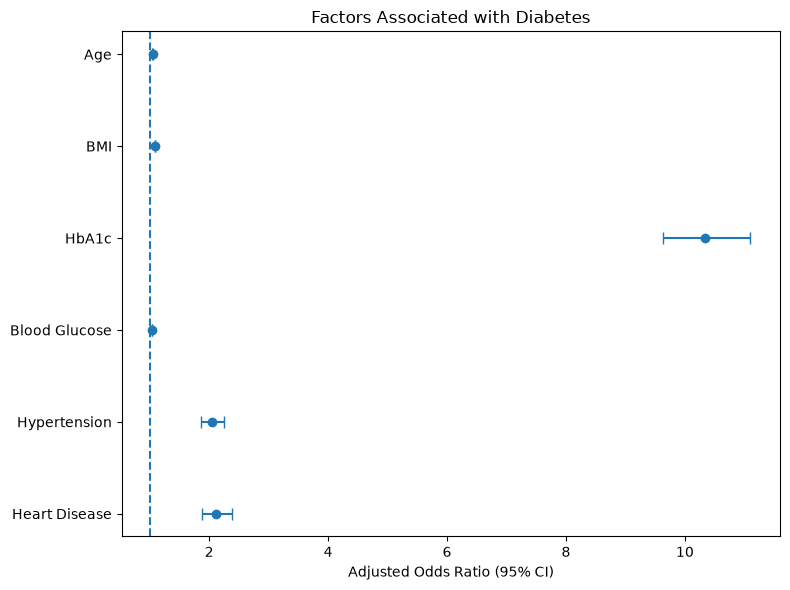

In [48]:
# Create a forest plot of adjusted odds ratios

fig, ax = plt.subplots(figsize=(8, 6))

y_positions = np.arange(len(forest_data))

odds_ratios = forest_data["Odds Ratio"].values
lower_ci = forest_data["CI Lower"].values
upper_ci = forest_data["CI Upper"].values

ax.errorbar(
    odds_ratios,
    y_positions,
    xerr=[
        odds_ratios - lower_ci,
        upper_ci - odds_ratios
    ],
    fmt="o",
    capsize=4
)

# Reference line for no association
ax.axvline(
    x=1,
    linestyle="--"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(forest_data["Variable"])

ax.set_xlabel("Adjusted Odds Ratio (95% CI)")
ax.set_title("Factors Associated with Diabetes")

ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretation

HbA1c showed the strongest association with diabetes in the adjusted model. Hypertension and heart disease were also associated with substantially higher odds of diabetes.

Age, BMI, and blood glucose showed smaller increases in odds for each one-unit increase. Because HbA1c had a much larger odds ratio than the other continuous variables, it dominates the scale of the figure.

## 11. Model Performance

After fitting the logistic regression model, I evaluated how well it distinguished patients with diabetes from patients without diabetes.

In [49]:
# Calculate predicted probability of diabetes for each patient

df_clean["predicted_probability"] = model_no_gender.predict(df_clean)

df_clean[
    ["diabetes", "predicted_probability"]
].head(10)

,diabetes,predicted_probability
0,0,0.43
1,0,0.01
2,0,0.01
3,0,0.00
4,0,0.02
5,0,0.00
6,1,0.19
7,0,0.00
8,0,0.00
9,0,0.00


In [50]:
# Import tools for evaluating the model

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Model evaluation tools loaded successfully.")

Model evaluation tools loaded successfully.


In [51]:
# Calculate the Area Under the ROC Curve

auc = roc_auc_score(
    df_clean["diabetes"],
    df_clean["predicted_probability"]
)

print(f"AUC: {auc:.3f}")

AUC: 0.961


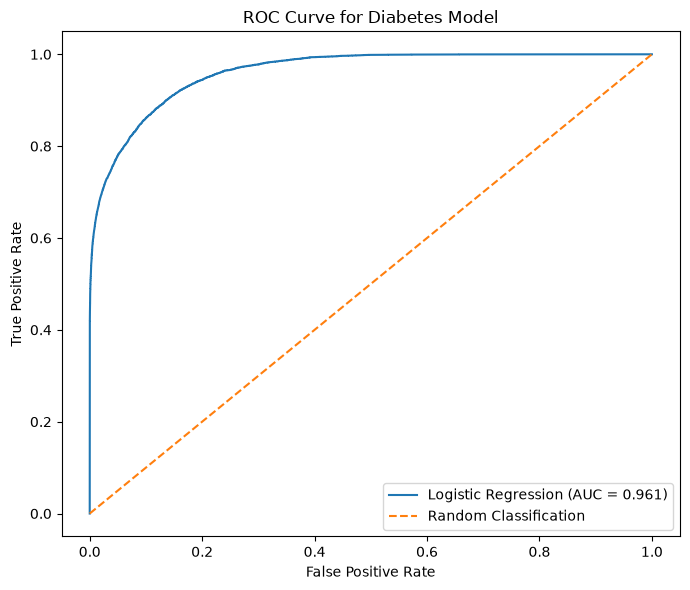

In [52]:
# Calculate values for the ROC curve

fpr, tpr, thresholds = roc_curve(
    df_clean["diabetes"],
    df_clean["predicted_probability"]
)

# Plot the ROC curve

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

# Reference line representing random classification
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classification"
)

ax.set_title("ROC Curve for Diabetes Model")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
plt.show()

### Model Performance

The logistic regression model achieved an AUC of 0.961, showing excellent ability to distinguish patients with diabetes from patients without diabetes.

However, HbA1c and blood glucose are clinical measures closely related to diabetes diagnosis. Their inclusion likely contributes substantially to the model's high performance. For this reason, the AUC should not be interpreted as the performance of a diabetes risk-screening model based only on general patient characteristics.

## 12. Risk-Factor Model

Question : How much predictive information do HbA1c and blood glucose add beyond age, BMI, smoking, hypertension, and heart disease?

Because HbA1c and blood glucose are closely related to the diagnosis of diabetes, I fitted a second model without these measurements.

This model focuses on general patient characteristics and existing health conditions to evaluate how well they distinguish patients with and without diabetes.

In [53]:
# Fit a model without HbA1c and blood glucose

risk_model = smf.logit(
    formula="""
        diabetes ~ age
        + bmi
        + hypertension
        + heart_disease
        + C(smoking_history)
    """,
    data=df_clean
).fit(maxiter=200)

print("Model converged:", risk_model.mle_retvals["converged"])

Optimization terminated successfully.
         Current function value: 0.237957
         Iterations 8
Model converged: True


In [54]:
# Calculate predictions from the risk-factor model

risk_probability = risk_model.predict(df_clean)

risk_auc = roc_auc_score(
    df_clean["diabetes"],
    risk_probability
)

print(f"Full model AUC: {auc:.3f}")
print(f"Risk-factor model AUC: {risk_auc:.3f}")

Full model AUC: 0.961
Risk-factor model AUC: 0.829


### Comparison of the Two Models

The full model achieved an AUC of 0.961, compared with 0.829 for the risk-factor model that excluded HbA1c and blood glucose.

The risk-factor model still showed good ability to distinguish patients with and without diabetes using age, BMI, hypertension, heart disease, and smoking history. Adding HbA1c and blood glucose substantially improved the model's performance.

This comparison also shows why the very high AUC of the full model should be interpreted carefully, since HbA1c and blood glucose are closely related to diabetes diagnosis.

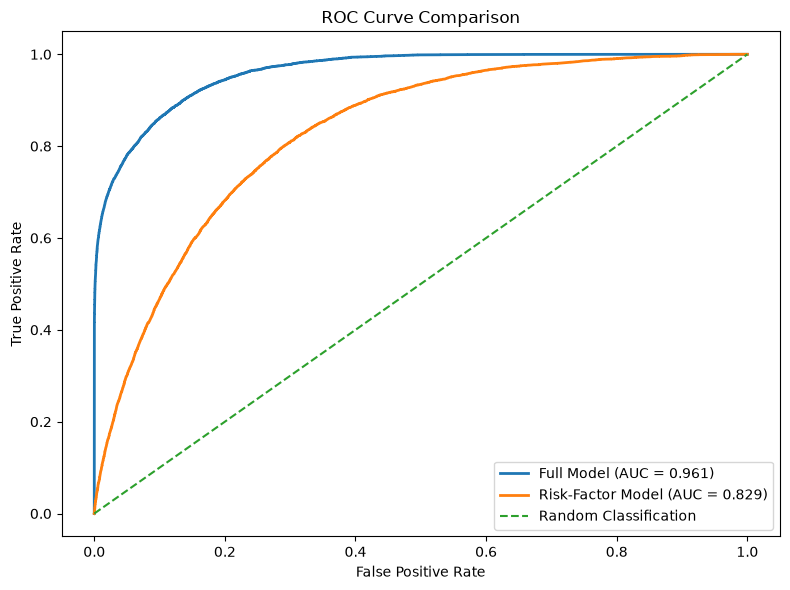

In [55]:
# ROC curves for both models

fpr_full, tpr_full, _ = roc_curve(
    df_clean["diabetes"],
    df_clean["predicted_probability"]
)

fpr_risk, tpr_risk, _ = roc_curve(
    df_clean["diabetes"],
    risk_probability
)

# Plot both ROC curves

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    fpr_full,
    tpr_full,
    linewidth=2,
    label=f"Full Model (AUC = {auc:.3f})"
)

ax.plot(
    fpr_risk,
    tpr_risk,
    linewidth=2,
    label=f"Risk-Factor Model (AUC = {risk_auc:.3f})"
)

# Reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classification"
)

ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation

Both models showed good ability to distinguish between patients with and without diabetes.

The full model achieved an AUC of 0.961, while the risk-factor model achieved an AUC of 0.829. The improvement in the full model is largely explained by the inclusion of HbA1c and blood glucose, which are strongly related to diabetes diagnosis.

The risk-factor model still performed well using patient characteristics and medical history alone, suggesting that these factors contain useful information for identifying patients at higher risk of diabetes.

## 12. Model Validation

To evaluate how well the model performs on new data, the dataset was divided into training and testing sets. The model was fitted using 80% of the observations and evaluated on the remaining 20%.

The diabetes outcome was stratified during the split so that the proportion of patients with diabetes remained similar in both datasets.

In [56]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

train_df, test_df = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=42,
    stratify=df_clean["diabetes"]
)

print(f"Training records: {len(train_df):,}")
print(f"Testing records: {len(test_df):,}")

print(
    f"Diabetes prevalence in training data: "
    f"{train_df['diabetes'].mean() * 100:.2f}%"
)

print(
    f"Diabetes prevalence in testing data: "
    f"{test_df['diabetes'].mean() * 100:.2f}%"
)

Training records: 76,916
Testing records: 19,230
Diabetes prevalence in training data: 8.82%
Diabetes prevalence in testing data: 8.82%


### Fit the Model on the Training Data

The logistic regression model was fitted using only the training data. The testing data was kept separate and was not used to estimate the model parameters.

In [57]:
# Fit of the full model using only the training data

train_model = smf.logit(
    formula="""
        diabetes ~ age
        + bmi
        + HbA1c_level
        + blood_glucose_level
        + hypertension
        + heart_disease
        + C(smoking_history)
    """,
    data=train_df
).fit(maxiter=200)

print("Model converged:", train_model.mle_retvals["converged"])

Optimization terminated successfully.
         Current function value: 0.116424
         Iterations 10
Model converged: True


### Evaluate the Model on the Testing Data

The fitted model was then used to calculate diabetes probabilities for patients in the testing dataset. Because these observations were not used to fit the model, this provides a better assessment of how the model performs on new data.

In [58]:
# Predict diabetes probabilities for the testing data

test_df = test_df.copy()

test_df["predicted_probability"] = train_model.predict(test_df)

# Calculate test AUC

test_auc = roc_auc_score(
    test_df["diabetes"],
    test_df["predicted_probability"]
)

print(f"Test AUC: {test_auc:.3f}")

Test AUC: 0.960


### Interpretation

The model achieved an AUC of 0.960 on the testing data, showing strong ability to distinguish between patients with and without diabetes.

The test AUC was very similar to the AUC observed before the train-test split, suggesting that the model's performance remained stable when applied to data that were not used to fit the model.

### Classification Performance

If we actually classify patients as diabetes or no diabetes, how many does the model get right?

Predicted probabilities were converted into diabetes classifications using a probability cutoff of 0.50. Patients with a predicted probability of 0.50 or higher were classified as having diabetes.

A confusion matrix was used to compare the predicted classifications with the observed diabetes status.

In [59]:
# Convert predicted probabilities into classifications

test_df["predicted_diabetes"] = (
    test_df["predicted_probability"] >= 0.50
).astype(int)

# Create confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_df["diabetes"],
    test_df["predicted_diabetes"]
)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(cm)

print(f"\nTrue Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

Confusion Matrix
[[17367   167]
 [  622  1074]]

True Negatives:  17,367
False Positives: 167
False Negatives: 622
True Positives:  1,074


### Interpretation

Using a probability cutoff of 0.50, the model correctly classified 17,367 patients without diabetes and 1,074 patients with diabetes.

The model incorrectly classified 167 patients without diabetes as having diabetes and missed 622 patients who actually had diabetes.

These results show that model performance depends not only on the model itself, but also on the probability cutoff used to classify patients.

In [60]:
# Calculate classification performance measures

accuracy = (tp + tn) / (tp + tn + fp + fn)

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

precision = tp / (tp + fp)

print(f"Accuracy:    {accuracy:.3f} ({accuracy * 100:.1f}%)")
print(f"Sensitivity: {sensitivity:.3f} ({sensitivity * 100:.1f}%)")
print(f"Specificity: {specificity:.3f} ({specificity * 100:.1f}%)")
print(f"Precision:   {precision:.3f} ({precision * 100:.1f}%)")

Accuracy:    0.959 (95.9%)
Sensitivity: 0.633 (63.3%)
Specificity: 0.990 (99.0%)
Precision:   0.865 (86.5%)


### Interpretation of Classification Performance

At a probability cutoff of 0.50, the model achieved 95.9% accuracy and 99.0% specificity, showing that it performed very well at correctly identifying patients without diabetes.

The sensitivity was 63.3%, meaning that the model identified about 63% of patients who actually had diabetes. Precision was 86.5%, meaning that when the model classified a patient as having diabetes, it was correct about 87% of the time.

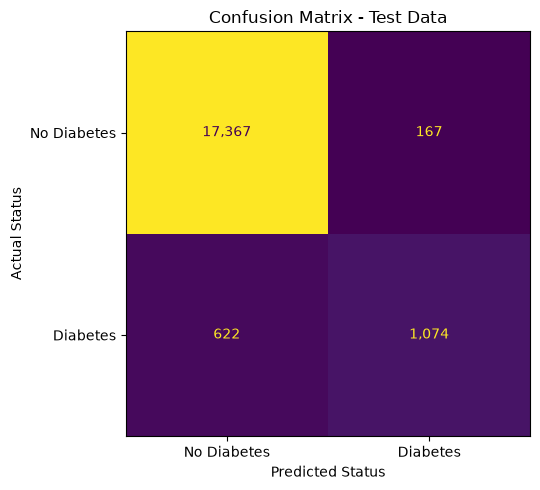

In [61]:
# Display the confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
).plot(
    ax=ax,
    values_format=",d",
    colorbar=False
)

ax.set_title("Confusion Matrix - Test Data")
ax.set_xlabel("Predicted Status")
ax.set_ylabel("Actual Status")

plt.tight_layout()
plt.show()

The confusion matrix shows that most patients were classified correctly. However, 622 patients with diabetes were classified as not having diabetes, compared with 167 patients without diabetes who were incorrectly classified as having diabetes.

This suggests that the 0.50 cutoff favors high specificity but misses a meaningful number of diabetes cases.

## 13. Classification Threshold Comparison

The probability cutoff determines when a patient is classified as having diabetes. A lower cutoff may identify more patients with diabetes, but it can also increase the number of patients incorrectly classified as having diabetes.

Several probability cutoffs were compared to examine the tradeoff between sensitivity, specificity, precision, and overall accuracy.

In [62]:
# Compare model performance at different probability cutoffs

thresholds = [0.20, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:

    predicted = (
        test_df["predicted_probability"] >= threshold
    ).astype(int)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(
        test_df["diabetes"],
        predicted
    ).ravel()

    sensitivity_t = tp_t / (tp_t + fn_t)
    specificity_t = tn_t / (tn_t + fp_t)
    precision_t = tp_t / (tp_t + fp_t)
    accuracy_t = (tp_t + tn_t) / len(test_df)

    threshold_results.append({
        "Cutoff": threshold,
        "Sensitivity": sensitivity_t,
        "Specificity": specificity_t,
        "Precision": precision_t,
        "Accuracy": accuracy_t
    })

threshold_table = pd.DataFrame(threshold_results)

# Display percentages
display_table = threshold_table.copy()

for column in [
    "Sensitivity",
    "Specificity",
    "Precision",
    "Accuracy"
]:
    display_table[column] = (
        display_table[column] * 100
    ).round(1)

display_table

,Cutoff,Sensitivity,Specificity,Precision,Accuracy
0,0.20,77.30,95.10,60.60,93.60
1,0.30,71.60,97.30,71.60,95.00
2,0.40,67.50,98.40,80.30,95.70
3,0.50,63.30,99.00,86.50,95.90


### Interpretation

Lowering the probability cutoff increased the model's ability to identify patients with diabetes, but it also increased the number of false-positive classifications.

At the standard 0.50 cutoff, sensitivity was 63.3% and specificity was 99.0%. Lowering the cutoff to 0.30 increased sensitivity to 71.6%, while specificity remained high at 97.3%.

At a cutoff of 0.20, sensitivity increased further to 77.3%, but precision decreased to 60.6%. This means that more diabetes cases were identified, but a larger proportion of patients classified as having diabetes were false positives.

The choice of cutoff therefore depends on the purpose of the analysis. If identifying more potential diabetes cases is a priority, a lower cutoff such as 0.30 may provide a more useful balance between sensitivity and specificity.

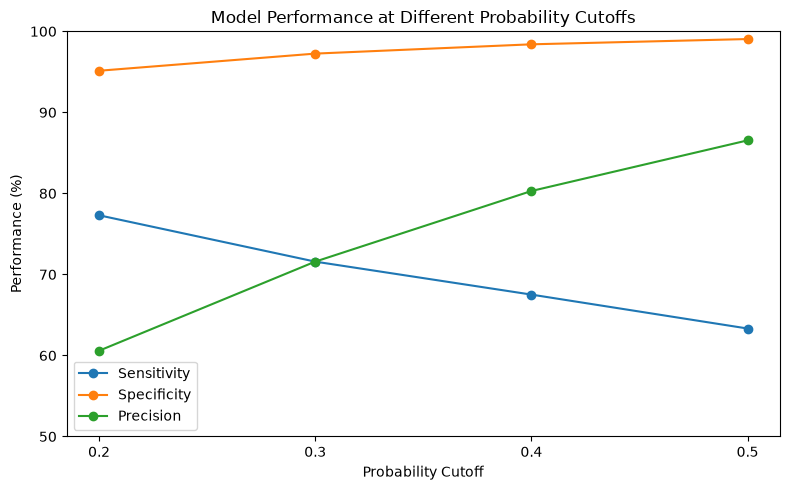

In [63]:
# Visualize the effect of the probability cutoff

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    threshold_table["Cutoff"],
    threshold_table["Sensitivity"] * 100,
    marker="o",
    label="Sensitivity"
)

ax.plot(
    threshold_table["Cutoff"],
    threshold_table["Specificity"] * 100,
    marker="o",
    label="Specificity"
)

ax.plot(
    threshold_table["Cutoff"],
    threshold_table["Precision"] * 100,
    marker="o",
    label="Precision"
)

ax.set_title("Model Performance at Different Probability Cutoffs")
ax.set_xlabel("Probability Cutoff")
ax.set_ylabel("Performance (%)")
ax.set_ylim(50, 100)
ax.set_xticks(thresholds)
ax.legend()

plt.tight_layout()
plt.show()

The figure shows the tradeoff created by changing the probability cutoff. Lower cutoffs improve sensitivity and identify more diabetes cases, while higher cutoffs improve specificity and precision.

A cutoff of 0.30 provides higher sensitivity than the standard 0.50 cutoff while maintaining high specificity.

In [64]:
# Save the cleaned dataset for the dashboard

output_path = "../data/processed/diabetes_clean.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Cleaned dataset saved successfully.")
print(f"Rows exported: {len(df_clean):,}")
print(f"Columns exported: {df_clean.shape[1]}")

Cleaned dataset saved successfully.
Rows exported: 96,146
Columns exported: 12


In [65]:
import os

print(os.getcwd())

C:\Users\kadri\OneDrive\Documents\diabetes-outcomes-analytics\Python


In [66]:
# Save the cleaned dataset for the dashboard

output_path = "../data/processed/diabetes_clean.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully.")
print(f"Rows exported: {len(df_clean):,}")
print(f"Columns exported: {df_clean.shape[1]}")

Cleaned dataset saved successfully.
Rows exported: 96,146
Columns exported: 12
